# Anagrams課題：条件・参加者差の分析

run_id: `v020-exp-11`。データ取得・分析はJupyter MCPのみ。Kaggle公開APIで検索・取得し、外部CSVミラーは使わない。数値列の意味が検証できるまでは「記録値」と呼び、正答率や因果効果と同一視しない。

フォローアップrun_id: `v020-exp-11-followup`。初回runと既存3回の依頼・セルIDは保持する。

## 実行環境・ライフサイクル

再実行は全コードセルを上からJupyter MCPで実行する。認証情報・環境変数の値・API例外本文は表示しない。検索・取得失敗時は停止する。

In [1]:
import os, io, json, hashlib, contextlib, warnings
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib.pyplot as plt
import nbformat
from IPython.display import display, Markdown
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, data_definition
from ai_data_scientist import analysis_assumptions, data_quality, sensitivity
from ai_data_scientist import visualization, insight_engine, notebook_audit
PROJECT = 'kaggle-v020-kaggle-exp-11-anagrams'
RUN_ID = 'v020-exp-11-followup'
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = '/home/nahisaho/GitHub/jupytermind/benchmark/projects'
handle = pm.resolve_project(PROJECT)
notebook_path = pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
language = language_router.detect_language('課題条件と参加者によるアナグラム測定値の違いを調べる')
lifecycle.register_run(RUN_ID, notebook_path)
events = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('実行中止要求を検出')
    lifecycle.mark_execution_start(RUN_ID)
    events.append({'phase':name, 'event':'execution_start', 'utc':datetime.now(timezone.utc).isoformat()})
    failed = False
    try:
        yield
    except Exception as exc:
        failed = True
        events.append({'phase':name, 'event':'failed', 'error_type':type(exc).__name__})
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        events.append({'phase':name, 'event':'execution_end', 'utc':datetime.now(timezone.utc).isoformat()})
        if failed:
            lifecycle.mark_failed(RUN_ID)
def notebook_write(mutation):
    lifecycle.mark_write_start(RUN_ID)
    events.append({'event':'write_start', 'utc':datetime.now(timezone.utc).isoformat()})
    try:
        return pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(RUN_ID)
        events.append({'event':'write_end', 'utc':datetime.now(timezone.utc).isoformat()})
def emit(tag, payload):
    display({'text/plain':tag + '=' + json.dumps(payload, ensure_ascii=False, sort_keys=True, default=str)},raw=True)
print('日本語分析、run_id:', RUN_ID)
print('保存先:', notebook_path)
emit('versions', {'numpy':np.__version__, 'pandas':pd.__version__, 'scipy':scipy.__version__})


日本語分析、run_id: v020-exp-11-followup
保存先: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-11-anagrams/notebooks/kaggle-v020-kaggle-exp-11-anagrams.ipynb


versions={"numpy": "2.5.3", "pandas": "3.0.6", "scipy": "1.18.1"}

## Kaggle検索・取得履歴

検索結果から課題名が一致する公開データを選ぶ。取得日時はUTC、SHA-256はダウンロードしたCSVの実バイト列で計算する。再実行時にもAPIから再取得し、最新の取得履歴を出力する。

In [2]:
from kaggle.api.kaggle_api_extended import KaggleApi
with phase('Kaggle検索・取得'):
    api = KaggleApi()
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.authenticate()
            found = api.dataset_list(search='anagrams')
        catalog = [{'ref':d.ref, 'title':d.title} for d in found]
        emit('KAGGLE_SEARCH', catalog)
        source_slug = 'sakshisatre/anagrams-dataset'
        if source_slug not in [d['ref'] for d in catalog]:
            raise LookupError('対応公開データが検索結果にないため実験を停止')
        file_catalog = api.dataset_list_files(source_slug)
        file_names = [f.name for f in file_catalog.files]
        emit('KAGGLE_FILES', file_names)
        file_name = 'anagrams.csv'
        if file_name not in file_names:
            raise LookupError('対応ファイルが存在しないため実験を停止')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(source_slug, file_name, path=str(data_dir), force=True, quiet=True)
            api.dataset_metadata(source_slug, path=str(data_dir))
    except Exception as exc:
        emit('KAGGLE_FAILURE', {'error_type':type(exc).__name__, 'action':'停止、外部ソースへのフォールバックなし'})
        raise RuntimeError('Kaggle APIによる対応データの検索・取得に失敗。例外本文は機密保護のため非表示。') from None
    data_path = data_dir / file_name
    sha256 = hashlib.sha256(data_path.read_bytes()).hexdigest()
    assert sha256 == '5eda074c9bc1d1ffb0a3988e36713fae520591d3e221e186efe9988baa054fc8', 'Kaggleファイル更新を検出。記録済み解釈を再評価するまで停止。'
    retrieval_utc = datetime.now(timezone.utc).isoformat()
    provenance = {'owner_dataset_slug':source_slug, 'file_name':file_name, 'retrieved_utc':retrieval_utc,
                  'sha256':sha256, 'bytes':data_path.stat().st_size, 'source_url':'https://www.kaggle.com/datasets/' + source_slug}
    emit('PROVENANCE', provenance)
    metadata = json.loads((data_dir / 'dataset-metadata.json').read_text())
    source_info = metadata['info']
    emit('SOURCE_DEFINITION', {k:source_info.get(k) for k in ['title','subtitle','description','userSpecifiedSources','licenses']})
    (data_dir / 'provenance.json').write_text(json.dumps(provenance,ensure_ascii=False,indent=2))


KAGGLE_SEARCH=[{"ref": "sakshisatre/anagrams-dataset", "title": "Anagrams Dataset"}, {"ref": "abdoomoh/all-seaborn-built-in-datasets", "title": "All Seaborn Built-in Datasets 📊✨"}]

KAGGLE_FILES=["anagrams.csv"]

PROVENANCE={"bytes": 399, "file_name": "anagrams.csv", "owner_dataset_slug": "sakshisatre/anagrams-dataset", "retrieved_utc": "2026-10-01T17:18:35.031000+00:00", "sha256": "5eda074c9bc1d1ffb0a3988e36713fae520591d3e221e186efe9988baa054fc8", "source_url": "https://www.kaggle.com/datasets/sakshisatre/anagrams-dataset"}

SOURCE_DEFINITION={"description": "![](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19517213%2F2baee69cd9611c30c4c535f2d10cc266%2F0_oiswHbCp26mU9Vrp.jpg?generation=1711294766233894&alt=media)\n\nThe \"anagrams\" dataset contains timings for solving anagrams under different conditions. An anagram is a word or phrase formed by rearranging the letters of a different word or phrase, typically using all the original letters exactly once. In this dataset, timings are recorded for solving anagrams, likely to analyze factors such as difficulty level, time taken under different conditions, or other experimental variables.\n\nEach entry in the dataset likely includes information such as:\n\n- The anagram itself\n- The time taken to solve the anagram\n- Conditions under which the anagram was solved \n\n**Columns**\n- subidr: Subject identifier or ID.\n\n- attnr: Attention condition, possibly indicating whether the subject was in a \"divided\" or \"focused\" atten

## データ形状と意味的な異常検査

参加者IDの一意性、欠損、注意条件の許容カテゴリ、数値の非負性を検査する。正答数なら整数であるという候補解釈も別に検査するが、定義不明のため非整数値を削除・丸めない。上限や正答率分母は根拠がなく設定しない。

In [3]:
with phase('形状・欠損・意味的異常'):
    ingestion_result = ingestion.ingest(ingestion.SourceSpec('csv', str(data_path)), row_limit=10000)
    raw = ingestion_result.dataframe
    clean_report = cleaning.clean_dataset(raw, operation='drop_duplicates')
    df = clean_report.dataframe
    emit('CLEANING', {k:v for k,v in asdict(clean_report).items() if k != 'dataframe'})
    assert not ingestion_result.truncated
    assert len(df) == len(raw), '重複除去が生じた場合は分析設計を再検討する'
    assert list(df.columns) == ['subidr','attnr','num1','num2','num3']
    eda_report = eda.explore(df)
    print(eda_report)
    display(df)
    schema = {'subidr':{'not_null':True,'unique':True,'min':1},
              'attnr':{'not_null':True,'allowed':['divided','focused']},
              **{c:{'not_null':True,'min':0} for c in ['num1','num2','num3']}}
    semantic_anomalies = data_quality.detect_anomalies(df,schema=schema)
    emit('SEMANTIC_CONSTRAINTS', [asdict(x) for x in semantic_anomalies])
    fractional = [{'subidr':int(r.subidr), 'column':c, 'value':float(getattr(r,c))}
                  for r in df.itertuples() for c in ['num1','num2','num3'] if getattr(r,c)%1 != 0]
    emit('NONINTEGER_VALUES', fractional)
    emit('DESIGN', {'participants':len(df), 'groups':df.groupby('attnr').size().to_dict(),
                   'measurements_per_participant':3, 'missing_cells':int(df.isna().sum().sum()),
                   'duplicate_ids':int(df.subidr.duplicated().sum()), 'accuracy_denominator_available':False})
    long = df.melt(id_vars=['subidr','attnr'],value_vars=['num1','num2','num3'],var_name='measurement',value_name='value')
    display(long.groupby(['attnr','measurement']).value.agg(['count','mean','std','median','min','max']))


EDAReport(describe={'subidr': {'count': 20.0, 'mean': 10.5, 'std': 5.916079783099616, 'min': 1.0, '25%': 5.75, '50%': 10.5, '75%': 15.25, 'max': 20.0}, 'num1': {'count': 20.0, 'mean': 5.35, 'std': 1.8431951662948316, 'min': 2.0, '25%': 4.75, '50%': 5.5, '75%': 6.25, 'max': 8.0}, 'num2': {'count': 20.0, 'mean': 5.975, 'std': 1.6739097001363383, 'min': 3.0, '25%': 5.0, '50%': 5.5, '75%': 7.25, 'max': 9.0}, 'num3': {'count': 20.0, 'mean': 6.55, 'std': 1.0990426455975697, 'min': 5.0, '25%': 6.0, '50%': 6.0, '75%': 7.0, 'max': 9.0}}, dtypes={'subidr': 'int64', 'attnr': 'str', 'num1': 'int64', 'num2': 'float64', 'num3': 'int64'}, non_null_counts={'subidr': 20, 'attnr': 20, 'num1': 20, 'num2': 20, 'num3': 20}, missing_summary={'subidr': {'missing_count': 0, 'missing_ratio': 0.0}, 'attnr': {'missing_count': 0, 'missing_ratio': 0.0}, 'num1': {'missing_count': 0, 'missing_ratio': 0.0}, 'num2': {'missing_count': 0, 'missing_ratio': 0.0}, 'num3': {'missing_count': 0, 'missing_ratio': 0.0}}, catego

CLEANING={"columns_affected": ["subidr", "attnr", "num1", "num2", "num3"], "rows_after": 20, "rows_before": 20, "rows_removed": 0}

,subidr,attnr,num1,num2,num3
0,1,divided,2,4.0,7
1,2,divided,3,4.0,5
2,3,divided,3,5.0,6
3,4,divided,5,7.0,5
4,5,divided,4,5.0,8
5,6,divided,5,5.0,6
6,7,divided,5,4.5,6
7,8,divided,5,7.0,8
8,9,divided,2,3.0,7
9,10,divided,6,5.0,6


SEMANTIC_CONSTRAINTS=[]

NONINTEGER_VALUES=[{"column": "num2", "subidr": 7, "value": 4.5}]

DESIGN={"accuracy_denominator_available": false, "duplicate_ids": 0, "groups": {"divided": 10, "focused": 10}, "measurements_per_participant": 3, "missing_cells": 0, "participants": 20}

count  mean       std  median  min  max
attnr   measurement                                         
divided num1            10  4.00  1.414214     4.5  2.0  6.0
        num2            10  4.95  1.257201     5.0  3.0  7.0
        num3            10  6.40  1.074968     6.0  5.0  8.0
focused num1            10  6.70  1.059350     6.5  5.0  8.0
        num2            10  7.00  1.414214     7.5  5.0  9.0
        num3            10  6.70  1.159502     6.5  5.0  9.0

## データ定義と分析前提

Kaggle説明は `timings` と述べる一方、`num1`〜`num3` の定義は `likely`、注意条件も `possibly` とする。単位、正誤、分母、課題難度、実施順、募集・割付方法は不明。ID 7 の `num2=4.5` は単純な整数正答数という解釈に整合しない。これは値の誤りと断定できず、そのまま保持する。

manifestでは確認済みのファイル同一性と未確認の意味を分離する。独立性・交換可能性・尺度比較可能性は結論上重要だが未検証であり、すべての推測統計はこれらを条件とする。正答率・因果効果という解釈は採用しない。

In [4]:
with phase('データ定義・分析前提manifest'):
    FV = data_definition.FieldValue
    variables = {
        'subidr': {'definition':FV('参加者識別子','verified','Kaggle metadata: Columns'),
                   'measurement_level':FV('名義尺度。数値大小を能力と解釈しない','inferred','列名と一意性')},
        'attnr': {'definition':FV('注意条件ラベル divided / focused','inferred','Kaggle説明はpossibly'),
                  'assignment':FV(None,'unknown','無作為割付方法なし')},
        **{c:{'definition':FV(None,'unknown','Kaggle説明はlikely numerical measurements'),
              'unit':FV(None,'unknown'), 'denominator':FV(None,'unknown'),
              'direction_better':FV(None,'unknown'),
              'within_subject_alignment':FV('同一参加者に記録された測定列','inferred','wide形式')}
           for c in ['num1','num2','num3']}}
    definition_manifest=data_definition.build_manifest(
        source=provenance, dataset_scope={'rows':len(df),'participants':20,'population':'unknown','source_claim':'timings, likely'},
        variables=variables, transformations=('完全重複の検査：0行除去','wideからlongへの変換。値は変更しない'))
    emit('DATA_DEFINITION_MANIFEST',asdict(definition_manifest))
    emit('UNRESOLVED_FIELDS',definition_manifest.unresolved_fields())
    A = analysis_assumptions.Assumption
    assumption_manifest=analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'outcome':'定義未検証の記録値','unit_of_inference':'参加者','tests':'探索的'},
        causal_scope='associational', sampling={'method':'Kaggleで公開された20人の便宜標本。募集方法不明','n':20,'seed':None},
        assumptions=(
            A('independent_subjects','参加者間は独立', 'assumed',impact_if_false='群間のCI・p値が不正確',conclusion_critical=True),
            A('exchangeable_labels','帰無仮説下の群ラベル交換可能性', 'assumed',impact_if_false='正確置換p値も妥当でない',conclusion_critical=True),
            A('numeric_comparability','3列は同一尺度の数値測定で比較可能', 'assumed',impact_if_false='平均・変化・交互作用の実質的解釈不能',conclusion_critical=True),
            A('same_participant','3列は同一IDに対応、60行を独立扱いしない','verified',impact_if_false='擬似反復'),
            A('complete_case','全20人で3列に欠損なし','verified'),
            A('accuracy','数値は正答率・整数正答数である','rejected',impact_if_false='正確さの断定を取り下げる',conclusion_critical=True),
            A('causal','群差は注意条件の因果効果である','rejected',impact_if_false='無作為割付・交絡情報なし')
        ))
    assumption_findings=analysis_assumptions.check_manifest(assumption_manifest)
    emit('ANALYSIS_ASSUMPTION_MANIFEST',asdict(assumption_manifest))
    emit('ASSUMPTION_FINDINGS',[asdict(f) for f in assumption_findings])
    (data_dir/'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,indent=2))
    (data_dir/'analysis-assumption-manifest.json').write_text(json.dumps(asdict(assumption_manifest),ensure_ascii=False,indent=2))


DATA_DEFINITION_MANIFEST={"dataset_scope": {"participants": 20, "population": "unknown", "rows": 20, "source_claim": "timings, likely"}, "source": {"bytes": 399, "file_name": "anagrams.csv", "owner_dataset_slug": "sakshisatre/anagrams-dataset", "retrieved_utc": "2026-10-01T17:18:35.031000+00:00", "sha256": "5eda074c9bc1d1ffb0a3988e36713fae520591d3e221e186efe9988baa054fc8", "source_url": "https://www.kaggle.com/datasets/sakshisatre/anagrams-dataset"}, "transformations": ["完全重複の検査：0行除去", "wideからlongへの変換。値は変更しない"], "variables": {"attnr": {"assignment": {"source": "無作為割付方法なし", "status": "unknown", "value": null}, "definition": {"source": "Kaggle説明はpossibly", "status": "inferred", "value": "注意条件ラベル divided / focused"}}, "num1": {"definition": {"source": "Kaggle説明はlikely numerical measurements", "status": "unknown", "value": null}, "denominator": {"source": null, "status": "unknown", "value": null}, "direction_better": {"source": null, "status": "unknown", "value": null}, "unit": {"source": 

UNRESOLVED_FIELDS=[["variables.attnr.assignment", "FieldValue(value=None, status='unknown', source='無作為割付方法なし')"], ["variables.num1.definition", "FieldValue(value=None, status='unknown', source='Kaggle説明はlikely numerical measurements')"], ["variables.num1.unit", "FieldValue(value=None, status='unknown', source=None)"], ["variables.num1.denominator", "FieldValue(value=None, status='unknown', source=None)"], ["variables.num1.direction_better", "FieldValue(value=None, status='unknown', source=None)"], ["variables.num2.definition", "FieldValue(value=None, status='unknown', source='Kaggle説明はlikely numerical measurements')"], ["variables.num2.unit", "FieldValue(value=None, status='unknown', source=None)"], ["variables.num2.denominator", "FieldValue(value=None, status='unknown', source=None)"], ["variables.num2.direction_better", "FieldValue(value=None, status='unknown', source=None)"], ["variables.num3.definition", "FieldValue(value=None, status='unknown', source='Kaggle説明はlikely numerical m

ANALYSIS_ASSUMPTION_MANIFEST={"analysis_scope": {"outcome": "定義未検証の記録値", "tests": "探索的", "unit_of_inference": "参加者"}, "assumptions": [{"conclusion_critical": true, "evidence_cell": null, "id": "independent_subjects", "impact_if_false": "群間のCI・p値が不正確", "statement": "参加者間は独立", "status": "assumed"}, {"conclusion_critical": true, "evidence_cell": null, "id": "exchangeable_labels", "impact_if_false": "正確置換p値も妥当でない", "statement": "帰無仮説下の群ラベル交換可能性", "status": "assumed"}, {"conclusion_critical": true, "evidence_cell": null, "id": "numeric_comparability", "impact_if_false": "平均・変化・交互作用の実質的解釈不能", "statement": "3列は同一尺度の数値測定で比較可能", "status": "assumed"}, {"conclusion_critical": false, "evidence_cell": null, "id": "same_participant", "impact_if_false": "擬似反復", "statement": "3列は同一IDに対応、60行を独立扱いしない", "status": "verified"}, {"conclusion_critical": false, "evidence_cell": null, "id": "complete_case", "impact_if_false": null, "statement": "全20人で3列に欠損なし", "status": "verified"}, {"conclusion_critical": tru

ASSUMPTION_FINDINGS=[{"assumption_id": "independent_subjects", "code": "unresolved_conclusion_critical_assumption", "message": "Conclusion-critical assumption 'independent_subjects' has status 'assumed', not verified/tested.", "severity": "warning"}, {"assumption_id": "exchangeable_labels", "code": "unresolved_conclusion_critical_assumption", "message": "Conclusion-critical assumption 'exchangeable_labels' has status 'assumed', not verified/tested.", "severity": "warning"}, {"assumption_id": "numeric_comparability", "code": "unresolved_conclusion_critical_assumption", "message": "Conclusion-critical assumption 'numeric_comparability' has status 'assumed', not verified/tested.", "severity": "warning"}, {"assumption_id": "accuracy", "code": "unresolved_conclusion_critical_assumption", "message": "Conclusion-critical assumption 'accuracy' has status 'rejected', not verified/tested.", "severity": "warning"}]

## データ形状を確認した後の分析計画

1. 20人（注意条件各10人）のwide形式を参加者単位で分析する。3列を独立な60人として扱わない。欠損補完・恣意的な外れ値削除はしない。
2. 群間比較は各測定列と参加者平均のfocused−divided差、Hedges g、参加者を条件内で再標本化する20,000回の95%区間。群ラベルの全184,756通りの置換による両側p値を求め、4比較にHolm補正する。データ確認後の探索計画であって事前登録ではない。
3. プロフィールの条件依存性は各人のnum2−num1、num3−num1をまとめた2次元統計の全ラベル置換で検査する。共分散は全参加者から固定してラベルに依存させない。num3−num1の群差と参加者bootstrap区間を併記する。
4. 同一参加者内の3列比較は対応t比較（各群の3比較にHolm）と補助的Friedman検定。正規性・同順位・尺度の仮定、小標本での漸近p値の限界を示す。時間順が不明なので学習効果と呼ばない。
5. 個人線、群平均、群差の区間、参加者別平均を可視化する。個人別の有意差や能力ランキングは推定しない。3観測だけで個人効果と誤差を分離するには弱い。
6. 初回結果を読み直して、意味定義、影響点・推定法、非有意結果の不確実性を最大3回追加検討する。独立検証標本がなければ再現実験と称さない。

In [5]:
with phase('参加者単位の統計比較'):
    metrics=['num1','num2','num3','participant_mean']
    scores=df[['num1','num2','num3']].to_numpy(dtype=float)
    work=df.copy()
    work['participant_mean']=scores.mean(axis=1)
    D=work.loc[work.attnr=='divided',metrics].to_numpy(float)
    F=work.loc[work.attnr=='focused',metrics].to_numpy(float)
    def mean_difference(f,d,axis=-1):
        return np.mean(f,axis=axis)-np.mean(d,axis=axis)
    def holm(p):
        p=np.asarray(p,float)
        order=np.argsort(p)
        q=np.empty(len(p))
        q[order]=np.minimum(1,np.maximum.accumulate(p[order]*(len(p)-np.arange(len(p)))))
        return q
    permutation=stats.permutation_test((F,D),mean_difference,permutation_type='independent',
        vectorized=True,n_resamples=np.inf,batch=2048,axis=0,alternative='two-sided')
    rng=np.random.default_rng(20261002)
    B=20000
    bootstrap_f=F[rng.integers(0,len(F),(B,len(F)))].mean(axis=1)
    bootstrap_d=D[rng.integers(0,len(D),(B,len(D)))].mean(axis=1)
    bootdiff=bootstrap_f-bootstrap_d
    ci=np.percentile(bootdiff,[2.5,97.5],axis=0)
    pooled_sd=np.sqrt(((len(F)-1)*F.var(axis=0,ddof=1)+(len(D)-1)*D.var(axis=0,ddof=1))/(len(F)+len(D)-2))
    correction=1-3/(4*(len(F)+len(D))-9)
    group_results=pd.DataFrame({'measurement':metrics,'divided_mean':D.mean(axis=0),'focused_mean':F.mean(axis=0),
        'difference_F_minus_D':F.mean(axis=0)-D.mean(axis=0),'ci95_low':ci[0],'ci95_high':ci[1],
        'hedges_g':correction*(F.mean(axis=0)-D.mean(axis=0))/pooled_sd,
        'p_exact':permutation.pvalue,'p_holm_4':holm(permutation.pvalue)})
    display(group_results)
    emit('GROUP_RESULTS',group_results.to_dict('records'))
    emit('RESAMPLING',{'exact_label_allocations':len(permutation.null_distribution),'bootstrap_subjects_per_group':10,
                       'bootstrap_runs':B,'seed':20261002,'confidence_interval':'percentile, pointwise, not simultaneous'})
    contrast=np.column_stack([scores[:,1]-scores[:,0],scores[:,2]-scores[:,0]])
    invcov=np.linalg.inv(np.cov(contrast,rowvar=False))
    def profile_stat(f,d,axis=-1):
        delta=np.mean(f,axis=axis)-np.mean(d,axis=axis)
        a,b=delta[0],delta[1]
        return invcov[0,0]*a*a+2*invcov[0,1]*a*b+invcov[1,1]*b*b
    CF=contrast[work.attnr.to_numpy()=='focused']
    CD=contrast[work.attnr.to_numpy()=='divided']
    profile_perm=stats.permutation_test((CF,CD),profile_stat,permutation_type='independent',vectorized=True,
        n_resamples=np.inf,batch=2048,axis=0,alternative='greater')
    changes_f=F[:,2]-F[:,0]
    changes_d=D[:,2]-D[:,0]
    change_boot=bootstrap_f[:,2]-bootstrap_f[:,0]-(bootstrap_d[:,2]-bootstrap_d[:,0])
    profile_result={'statistic':float(profile_perm.statistic),'p_exact':float(profile_perm.pvalue),
        'num3_minus_num1_divided':float(changes_d.mean()),'num3_minus_num1_focused':float(changes_f.mean()),
        'difference_in_change':float(changes_f.mean()-changes_d.mean()),
        'difference_in_change_ci95':np.percentile(change_boot,[2.5,97.5]).tolist()}
    emit('PROFILE_INTERACTION',profile_result)
    within_results=[]
    for group in ['all','divided','focused']:
        z=scores if group=='all' else work.loc[work.attnr==group,['num1','num2','num3']].to_numpy(float)
        fr=stats.friedmanchisquare(*z.T)
        pairs=[('num2-num1',1,0),('num3-num1',2,0),('num3-num2',2,1)]
        tests=[]
        for label,j,k in pairs:
            diff=z[:,j]-z[:,k]
            result=stats.ttest_1samp(diff,0)
            se=stats.sem(diff)
            limits=stats.t.interval(.95,len(diff)-1,loc=diff.mean(),scale=se)
            tests.append({'group':group,'contrast':label,'n_subjects':len(z),'mean_change':float(diff.mean()),
                          'ci95_low':float(limits[0]),'ci95_high':float(limits[1]),'p_paired_t':float(result.pvalue)})
        for row,padj in zip(tests,holm([r['p_paired_t'] for r in tests])):
            row['p_holm_within_group']=float(padj)
        within_results.extend(tests)
        emit('FRIEDMAN_'+group,{'statistic':float(fr.statistic),'p_approx':float(fr.pvalue),
                              'limitation':'漸近p値。小標本・同順位あり。補助的結果'})
    display(pd.DataFrame(within_results))
    emit('WITHIN_RESULTS',within_results)
    individuals=work[['subidr','attnr','participant_mean']].copy()
    individuals['within_range']=scores.max(axis=1)-scores.min(axis=1)
    display(individuals)
    emit('PARTICIPANT_VARIATION',{'mean_range':[float(individuals.participant_mean.min()),float(individuals.participant_mean.max())],
                                'within_range':[float(individuals.within_range.min()),float(individuals.within_range.max())]})


,measurement,divided_mean,focused_mean,difference_F_minus_D,ci95_low,ci95_high,hedges_g,p_exact,p_holm_4
0,num1,4.000000,6.7,2.700000,1.70,3.700000,2.069652,0.000281,0.001126
1,num2,4.950000,7.0,2.050000,0.90,3.150000,1.467385,0.006040,0.012081
2,num3,6.400000,6.7,0.300000,-0.60,1.200000,0.256990,0.692708,0.692708
3,participant_mean,5.116667,6.8,1.683333,0.95,2.433333,1.796792,0.001018,0.003053


GROUP_RESULTS=[{"ci95_high": 3.7, "ci95_low": 1.6999999999999993, "difference_F_minus_D": 2.7, "divided_mean": 4.0, "focused_mean": 6.7, "hedges_g": 2.0696524443980584, "measurement": "num1", "p_exact": 0.00028145229383619476, "p_holm_4": 0.001125809175344779}, {"ci95_high": 3.1499999999999995, "ci95_low": 0.9000000000000004, "difference_F_minus_D": 2.05, "divided_mean": 4.95, "focused_mean": 7.0, "hedges_g": 1.4673854706442997, "measurement": "num2", "p_exact": 0.0060403992292537186, "p_holm_4": 0.012080798458507437}, {"ci95_high": 1.2000000000000002, "ci95_low": -0.6000000000000005, "difference_F_minus_D": 0.2999999999999998, "divided_mean": 6.4, "focused_mean": 6.7, "hedges_g": 0.2569903478365954, "measurement": "num3", "p_exact": 0.6927082205719977, "p_holm_4": 0.6927082205719977}, {"ci95_high": 2.4333333333333327, "ci95_low": 0.9500000000000002, "difference_F_minus_D": 1.6833333333333336, "divided_mean": 5.116666666666666, "focused_mean": 6.8, "hedges_g": 1.796791862156474, "measu

RESAMPLING={"bootstrap_runs": 20000, "bootstrap_subjects_per_group": 10, "confidence_interval": "percentile, pointwise, not simultaneous", "exact_label_allocations": 184756, "seed": 20261002}

PROFILE_INTERACTION={"difference_in_change": -2.4, "difference_in_change_ci95": [-3.7, -1.0], "num3_minus_num1_divided": 2.4, "num3_minus_num1_focused": 0.0, "p_exact": 0.00010283833813245579, "statistic": 1.4375403641360354}

FRIEDMAN_all={"limitation": "漸近p値。小標本・同順位あり。補助的結果", "p_approx": 0.14956861922263362, "statistic": 3.8000000000000194}

...

FRIEDMAN_focused={"limitation": "漸近p値。小標本・同順位あり。補助的結果", "p_approx": 0.2265366618129549, "statistic": 2.9696969696969733}

,group,contrast,n_subjects,mean_change,ci95_low,ci95_high,p_paired_t,p_holm_within_group
0,all,num2-num1,20,0.625,0.127871,1.122129,0.016444,0.046163
1,all,num3-num1,20,1.200,0.256610,2.143390,0.015388,0.046163
2,all,num3-num2,20,0.575,-0.294878,1.444878,0.182548,0.182548
3,divided,num2-num1,10,0.950,0.151096,1.748904,0.024797,0.041776
4,divided,num3-num1,10,2.400,1.042706,3.757294,0.003110,0.009331
5,divided,num3-num2,10,1.450,0.276364,2.623636,0.020888,0.041776
6,focused,num2-num1,10,0.300,-0.378647,0.978647,0.343436,1.000000
7,focused,num3-num1,10,0.000,-0.953809,0.953809,1.000000,1.000000
8,focused,num3-num2,10,-0.300,-1.518209,0.918209,0.591051,1.000000


WITHIN_RESULTS=[{"ci95_high": 1.1221294481673416, "ci95_low": 0.1278705518326585, "contrast": "num2-num1", "group": "all", "mean_change": 0.625, "n_subjects": 20, "p_holm_within_group": 0.04616256939784967, "p_paired_t": 0.016444066309954184}, {"ci95_high": 2.143389572161573, "ci95_low": 0.2566104278384266, "contrast": "num3-num1", "group": "all", "mean_change": 1.2, "n_subjects": 20, "p_holm_within_group": 0.04616256939784967, "p_paired_t": 0.015387523132616557}, {"ci95_high": 1.444878179508681, "ci95_low": -0.2948781795086811, "contrast": "num3-num2", "group": "all", "mean_change": 0.575, "n_subjects": 20, "p_holm_within_group": 0.18254817886804348, "p_paired_t": 0.18254817886804348}, {"ci95_high": 1.7489041814521888, "ci95_low": 0.15109581854781107, "contrast": "num2-num1", "group": "divided", "mean_change": 0.95, "n_subjects": 10, "p_holm_within_group": 0.04177579711542717, "p_paired_t": 0.024796666870849766}, {"ci95_high": 3.7572942976789228, "ci95_low": 1.042705702321077, "contra

,subidr,attnr,participant_mean,within_range
0,1,divided,4.333333,5.0
1,2,divided,4.000000,2.0
2,3,divided,4.666667,3.0
3,4,divided,5.666667,2.0
4,5,divided,5.666667,4.0
5,6,divided,5.333333,1.0
6,7,divided,5.166667,1.5
7,8,divided,6.666667,3.0
8,9,divided,4.000000,5.0
9,10,divided,5.666667,1.0


PARTICIPANT_VARIATION={"mean_range": [4.0, 8.333333333333334], "within_range": [1.0, 5.0]}

## 図表

バーの平均だけで判断せず、同一参加者の線と参加者単位の不確実性を併記する。値の大小を良し悪しと解釈しない。

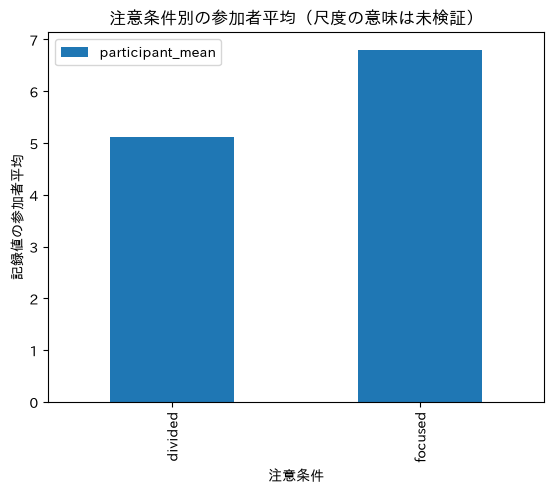

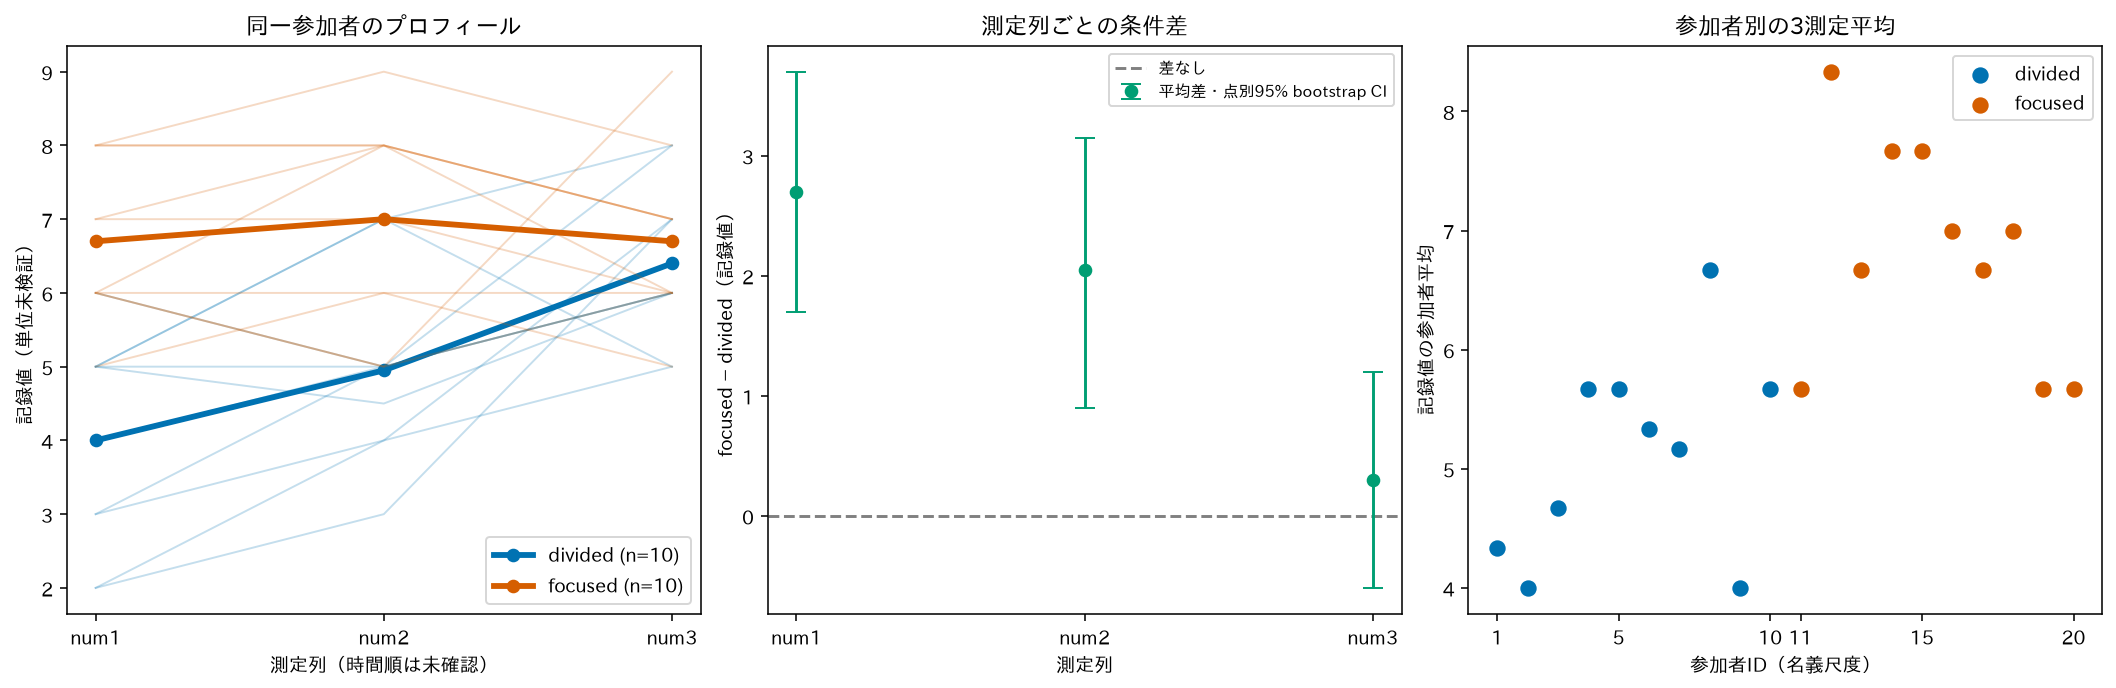

CHART_PROVENANCE={"images": 2, "legend": ["divided", "focused", "差なし", "平均差・点別95% bootstrap CI"], "missing_glyphs": [], "notes": "IDの順序は能力順位でない。線は同じ参加者を結ぶ。CIは同時区間ではない。"}

In [6]:
with phase('図表作成'), plt.rc_context({'savefig.bbox':'tight'}), warnings.catch_warnings(record=True) as chart_warnings:
    warnings.simplefilter('always')
    bar_data=work.groupby('attnr',as_index=False).participant_mean.mean()
    overview_png=visualization.render_chart(bar_data,kind='bar',x='attnr',y='participant_mean',
        title='注意条件別の参加者平均（尺度の意味は未検証）',xlabel='注意条件',ylabel='記録値の参加者平均')
    overview_output=visualization.build_image_output(overview_png)
    display(overview_output['data'],raw=True)
    fig,axes=plt.subplots(1,3,figsize=(15,4.8),constrained_layout=True)
    colors={'divided':'#0072B2','focused':'#D55E00'}
    for group in ['divided','focused']:
        subset=work[work.attnr==group]
        vals=subset[['num1','num2','num3']].to_numpy(float)
        for row in vals:
            axes[0].plot(range(3),row,color=colors[group],alpha=.23,lw=1)
        axes[0].plot(range(3),vals.mean(axis=0),'-o',color=colors[group],lw=3,label=group+' (n=10)')
        axes[2].scatter(subset.subidr,subset.participant_mean,color=colors[group],label=group,s=55)
    axes[0].set(xticks=range(3),xticklabels=['num1','num2','num3'],title='同一参加者のプロフィール',xlabel='測定列（時間順は未確認）',ylabel='記録値（単位未検証）')
    axes[0].legend()
    gr=group_results.iloc[:3]
    axes[1].axhline(0,color='gray',ls='--',label='差なし')
    axes[1].errorbar(range(3),gr.difference_F_minus_D,
        yerr=np.vstack([gr.difference_F_minus_D-gr.ci95_low,gr.ci95_high-gr.difference_F_minus_D]),
        fmt='o',capsize=5,color='#009E73',label='平均差・点別95% bootstrap CI')
    axes[1].set(xticks=range(3),xticklabels=['num1','num2','num3'],title='測定列ごとの条件差',xlabel='測定列',ylabel='focused − divided（記録値）')
    axes[1].legend(fontsize=8)
    axes[2].set(title='参加者別の3測定平均',xlabel='参加者ID（名義尺度）',ylabel='記録値の参加者平均',xticks=[1,5,10,11,15,20])
    axes[2].legend()
    buf=io.BytesIO()
    fig.savefig(buf,format='png',dpi=140)
    plt.close(fig)
    profile_png=buf.getvalue()
    display(visualization.build_image_output(profile_png)['data'],raw=True)
    glyph_messages=[str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
    assert not glyph_messages, '日本語glyph欠落を検出'
    emit('CHART_PROVENANCE',{'images':2,'missing_glyphs':glyph_messages,
        'legend':['divided','focused','差なし','平均差・点別95% bootstrap CI'],
        'notes':'IDの順序は能力順位でない。線は同じ参加者を結ぶ。CIは同時区間ではない。'})


## 反復依頼履歴

### 反復1：原文

Kaggle説明の「所要時間」と正確さという目的の不整合を再検討してください。同じ検索で見つかった別のKaggle公開データのanagramsファイルと説明をAPIから取得し、値と参加者IDを照合してください。コピーの一致を独立標本による再現と扱わず、正答率の結論が可能か判断してください。

**選定理由**：数値の意味を取り違えると、差の方向さえ逆になりうるため。初回出力 `SOURCE_DEFINITION` と `NONINTEGER_VALUES` が根拠。

In [7]:
from ai_data_scientist import dataset_validation
with phase('反復1：定義とKaggle上の同源コピー照合'):
    candidate_slug='abdoomoh/all-seaborn-built-in-datasets'
    candidate_name='Seaborn All Built-in Datasets/anagrams.csv'
    candidate_dir=data_dir/'candidate'
    candidate_dir.mkdir(exist_ok=True)
    try:
        listed=api.dataset_list_files(candidate_slug,page_size=100)
        assert candidate_name in [f.name for f in listed.files]
        with contextlib.redirect_stdout(io.StringIO()),contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(candidate_slug,candidate_name,path=str(candidate_dir),force=True,quiet=True)
            api.dataset_metadata(candidate_slug,path=str(candidate_dir))
    except Exception as exc:
        emit('CANDIDATE_API_FAILURE',{'error_type':type(exc).__name__})
        raise RuntimeError('Kaggle候補ファイルを取得できない。外部ソースへのフォールバックは行わない。') from None
    candidate_paths=list(candidate_dir.rglob('anagrams.csv'))
    assert len(candidate_paths)==1, '取得ファイルを一意に特定できない'
    candidate_path=candidate_paths[0]
    candidate_provenance={'owner_dataset_slug':candidate_slug,'file_name':candidate_name,
        'retrieved_utc':datetime.now(timezone.utc).isoformat(),
        'sha256':hashlib.sha256(candidate_path.read_bytes()).hexdigest(),'bytes':candidate_path.stat().st_size}
    emit('CANDIDATE_PROVENANCE',candidate_provenance)
    candidate_meta=json.loads((candidate_dir/'dataset-metadata.json').read_text())
    emit('CANDIDATE_DESCRIPTION',candidate_meta['info'].get('description'))
    candidate=ingestion.ingest(ingestion.SourceSpec('csv',str(candidate_path)),row_limit=10000).dataframe
    comparison=dataset_validation.compare_datasets(df,candidate,key_mapping={'subidr':'subidr'},
        value_mapping={c:c for c in ['attnr','num1','num2','num3']},candidate_relationship='derived')
    emit('DATASET_COMPARISON',asdict(comparison))
    copy_result={'byte_identical':candidate_provenance['sha256']==sha256,
                 'matched_subjects':comparison.matched_keys,'independent_replication':False,
                 'accuracy_definition_verified':False,'decision':'正答率は算出せず、記録値の条件差に限定'}
    emit('ITERATION1_RESULT',copy_result)
    (candidate_dir/'provenance.json').write_text(json.dumps(candidate_provenance,ensure_ascii=False,indent=2))


CANDIDATE_PROVENANCE={"bytes": 420, "file_name": "Seaborn All Built-in Datasets/anagrams.csv", "owner_dataset_slug": "abdoomoh/all-seaborn-built-in-datasets", "retrieved_utc": "2026-10-01T17:19:02.774457+00:00", "sha256": "17af9bb054e0c371779ec5bd364baae916a923fe747049271dab1f3bd592003a"}

CANDIDATE_DESCRIPTION="**Description:**\n- This dataset includes all 22 built-in datasets from the Seaborn library, a widely used Python data visualization tool. Seaborn's built-in datasets are essential resources for anyone interested in practicing data analysis, visualization, and machine learning. They span a wide range of topics, from classic datasets like the Iris flower classification to real-world data such as Titanic survival records and diamond characteristics.\n\n- **Included Datasets:**\n  - **Anagrams**: Analysis of word anagram patterns.\n  - **Anscombe**: Anscombe's quartet demonstrating the importance of data visualization.\n  - **Attention**: Data on attention span variations in different scenarios.\n  - **Brain Networks**: Connectivity data within brain networks.\n  - **Car Crashes**: US car crash statistics.\n  - **Diamonds**: Data on diamond properties including price, cut, and clarity.\n  - **Dots**: Randomly generated data for scatter plot visualization.\n  - **Dow

DATASET_COMPARISON={"candidate_only_keys": 0, "candidate_relationship": "derived", "column_comparisons": [{"agreement_rate": 1.0, "candidate_column": "attnr", "matched_rows": 20, "mismatched_rows": 0, "primary_column": "attnr"}, {"agreement_rate": 1.0, "candidate_column": "num1", "matched_rows": 20, "mismatched_rows": 0, "primary_column": "num1"}, {"agreement_rate": 1.0, "candidate_column": "num2", "matched_rows": 20, "mismatched_rows": 0, "primary_column": "num2"}, {"agreement_rate": 1.0, "candidate_column": "num3", "matched_rows": 20, "mismatched_rows": 0, "primary_column": "num3"}], "matched_keys": 20, "primary_only_keys": 0}

ITERATION1_RESULT={"accuracy_definition_verified": false, "byte_identical": false, "decision": "正答率は算出せず、記録値の条件差に限定", "independent_replication": false, "matched_subjects": 20}

### 反復2：原文

各群10人という少数標本で見えた群差とプロフィール差が、1人の参加者や非整数値、平均という推定法だけに依存していないか調べてください。1人ずつの除外、ID 7の除外、中央値と10%トリム平均を感度分析し、順位ベースの群間比較と参加者内の符号検定も補助的に実行してください。方向の安定性と効果量の安定性を分けて報告してください。

**選定理由**：初回 `GROUP_RESULTS` と `PROFILE_INTERACTION` では数値差が大きいが、各群10人しかなく、`NONINTEGER_VALUES` のID 7も未解決。意味定義の追加照合（反復1）ではこれ以上の解決ができなかったため、推定の頑健性を検討する。

**設計**：22部分標本 × 3推定法 = 66仕様を、参加者平均差とnum3−num1の群差にそれぞれ適用。許容相対偏差25%は分析上の診断基準であり、科学的な同等性閾値ではない。

In [8]:
with phase('反復2：参加者・推定法の感度分析'):
    subset_grid=['all','exclude_7']+['leave_'+str(int(i)) for i in work.subidr]
    plan=sensitivity.SensitivityPlan(parameter_grid={'subset':subset_grid,'estimator':['mean','median','trim10']},max_runs=66)
    def estimate(values,estimator):
        if estimator=='mean':
            return float(np.mean(values))
        if estimator=='median':
            return float(np.median(values))
        if estimator=='trim10':
            return float(stats.trim_mean(values,.1))
        raise ValueError('unknown estimator')
    def sensitivity_effect(subset,estimator,outcome):
        z=work if subset=='all' else work[work.subidr!=(7 if subset=='exclude_7' else int(subset.split('_')[1]))]
        values=z.participant_mean.to_numpy() if outcome=='mean' else (z.num3-z.num1).to_numpy()
        labels=z.attnr.to_numpy()
        return estimate(values[labels=='focused'],estimator)-estimate(values[labels=='divided'],estimator)
    sensitivity_reports={}
    sensitivity_summary={}
    for outcome in ['mean','profile_change']:
        report=sensitivity.run_sensitivity(plan,lambda subset,estimator:sensitivity_effect(subset,estimator,outcome),stability_tolerance=.25)
        sensitivity_reports[outcome]=report
        values=np.array([r.value for r in report.results])
        sensitivity_summary[outcome]={'runs':len(values),'baseline':report.baseline_value,'stable':report.stable,
            'max_relative_deviation':report.max_relative_deviation,'minimum':float(values.min()),'maximum':float(values.max()),
            'same_direction':bool(np.all(values>0) if outcome=='mean' else np.all(values<0)),'stability_tolerance':.25}
        display(pd.DataFrame([dict(r.specification,value=r.value) for r in report.results]).sort_values('value').iloc[np.r_[0:5,-5:0]])
    emit('SENSITIVITY_SUMMARY',sensitivity_summary)
    (data_dir/'sensitivity-results.json').write_text(json.dumps({k:asdict(v) for k,v in sensitivity_reports.items()},ensure_ascii=False,indent=2))
    ranked=stats.rankdata(work[metrics].to_numpy(float),axis=0)
    rank_perm=stats.permutation_test((ranked[work.attnr=='focused'],ranked[work.attnr=='divided']),mean_difference,
        permutation_type='independent',vectorized=True,n_resamples=np.inf,batch=2048,axis=0,alternative='two-sided')
    rank_results=[{'measurement':m,'mean_rank_difference':float(e),'p_exact':float(p),'p_holm_4':float(q)}
                  for m,e,p,q in zip(metrics,rank_perm.statistic,rank_perm.pvalue,holm(rank_perm.pvalue))]
    emit('RANK_COMPARISON',rank_results)
    sign_results=[]
    for group in ['all','divided','focused']:
        z=work if group=='all' else work[work.attnr==group]
        rows=[]
        for name,j,k in [('num2-num1','num2','num1'),('num3-num1','num3','num1'),('num3-num2','num3','num2')]:
            d=(z[j]-z[k]).to_numpy()
            positive=int((d>0).sum());negative=int((d<0).sum());ties=int((d==0).sum())
            assert positive+negative>0
            p=float(stats.binomtest(positive,positive+negative,.5,alternative='two-sided').pvalue)
            rows.append({'group':group,'contrast':name,'positive':positive,'negative':negative,'ties_excluded':ties,'p_sign_exact':p})
        for row,q in zip(rows,holm([r['p_sign_exact'] for r in rows])):
            row['p_holm_3']=float(q)
        sign_results.extend(rows)
    display(pd.DataFrame(sign_results))
    emit('SIGN_COMPARISON',sign_results)
    emit('ITERATION2_LIMITS',{'rank_test':'平均差ではなく順位分布差の補助検査',
        'sign_test':'ゼロ差を除外した正負比を検査。対応tと帰無仮説が異なり、低検出力。',
        'units':'感度分析は単位・課題意味を検証しない','trim10':'n=9ではfloor(0.1*n)=0でトリムなしとなる'})


,subset,estimator,value
49,leave_15,median,1.416667
52,leave_16,median,1.416667
40,leave_12,median,1.416667
58,leave_18,median,1.416667
46,leave_14,median,1.416667
36,leave_11,mean,1.809259
27,leave_8,mean,1.855556
38,leave_11,trim10,1.863426
62,leave_19,trim10,1.863426
65,leave_20,trim10,1.863426


,subset,estimator,value
4,exclude_7,median,-3.500000
10,leave_2,median,-3.500000
22,leave_6,median,-3.500000
16,leave_4,median,-3.500000
25,leave_7,median,-3.500000
50,leave_15,trim10,-2.263889
65,leave_20,trim10,-2.263889
18,leave_5,mean,-2.222222
6,leave_1,mean,-2.111111
30,leave_9,mean,-2.111111


SENSITIVITY_SUMMARY={"mean": {"baseline": 1.6833333333333336, "max_relative_deviation": 0.15841584158415836, "maximum": 1.8634259259259265, "minimum": 1.416666666666667, "runs": 66, "same_direction": true, "stability_tolerance": 0.25, "stable": true}, "profile_change": {"baseline": -2.4, "max_relative_deviation": 0.45833333333333337, "maximum": -2.111111111111111, "minimum": -3.5, "runs": 66, "same_direction": true, "stability_tolerance": 0.25, "stable": false}}

RANK_COMPARISON=[{"mean_rank_difference": 9.0, "measurement": "num1", "p_exact": 0.00028145229383619476, "p_holm_4": 0.001125809175344779}, {"mean_rank_difference": 7.3999999999999995, "measurement": "num2", "p_exact": 0.0026954469678927883, "p_holm_4": 0.0053908939357855765}, {"mean_rank_difference": 1.3999999999999986, "measurement": "num3", "p_exact": 0.6006191950464397, "p_holm_4": 0.6006191950464397}, {"mean_rank_difference": 8.3, "measurement": "participant_mean", "p_exact": 0.0009417826755288056, "p_holm_4": 0.0028253480265864168}]

,group,contrast,positive,negative,ties_excluded,p_sign_exact,p_holm_3
0,all,num2-num1,11,4,5,0.118469,0.355408
1,all,num3-num1,11,5,4,0.210114,0.420227
2,all,num3-num2,11,8,1,0.647606,0.647606
3,divided,num2-num1,7,2,1,0.179688,0.179688
4,divided,num3-num1,8,0,2,0.007812,0.023438
5,divided,num3-num2,9,1,0,0.021484,0.042969
6,focused,num2-num1,4,2,4,0.687500,1.000000
7,focused,num3-num1,3,5,2,0.726562,1.000000
8,focused,num3-num2,2,7,1,0.179688,0.539062


SIGN_COMPARISON=[{"contrast": "num2-num1", "group": "all", "negative": 4, "p_holm_3": 0.35540771484374994, "p_sign_exact": 0.11846923828124999, "positive": 11, "ties_excluded": 5}, {"contrast": "num3-num1", "group": "all", "negative": 5, "p_holm_3": 0.42022705078125, "p_sign_exact": 0.210113525390625, "positive": 11, "ties_excluded": 4}, {"contrast": "num3-num2", "group": "all", "negative": 8, "p_holm_3": 0.6476058959960938, "p_sign_exact": 0.6476058959960938, "positive": 11, "ties_excluded": 1}, {"contrast": "num2-num1", "group": "divided", "negative": 2, "p_holm_3": 0.1796875, "p_sign_exact": 0.1796875, "positive": 7, "ties_excluded": 1}, {"contrast": "num3-num1", "group": "divided", "negative": 0, "p_holm_3": 0.0234375, "p_sign_exact": 0.0078125, "positive": 8, "ties_excluded": 2}, {"contrast": "num3-num2", "group": "divided", "negative": 1, "p_holm_3": 0.04296875, "p_sign_exact": 0.021484375, "positive": 9, "ties_excluded": 0}, {"contrast": "num2-num1", "group": "focused", "negativ

ITERATION2_LIMITS={"rank_test": "平均差ではなく順位分布差の補助検査", "sign_test": "ゼロ差を除外した正負比を検査。対応tと帰無仮説が異なり、低検出力。", "trim10": "n=9ではfloor(0.1*n)=0でトリムなしとなる", "units": "感度分析は単位・課題意味を検証しない"}

### 反復3：原文

num3で有意な群差がなかったことを「同じ正確さ」と誤読しないように、Welchの信頼区間と仮の同等性マージン0.5・1・2記録値単位によるTOSTを示してください。閾値の科学的根拠がないこと、少数標本でどの程度の差が見逃されうるか、符号検定と対応t検定が一致しなかった参加者内の結果も踏まえて、結論の強さを調整してください。

**選定理由**：初回num3の区間が0を含み、反復2でもnum3は非有意だった一方、群平均との差の方向は維持された。「差がない」と「同等」を区別し、方法依存の参加者内結果を弱める必要がある。仮のマージンは感度確認であり科学的な実用同等性基準ではない。

In [9]:
with phase('反復3：非有意と同等性・精度の区別'):
    f=F[:,2];d=D[:,2]
    diff=float(f.mean()-d.mean())
    vf=f.var(ddof=1)/len(f);vd=d.var(ddof=1)/len(d)
    se=float(np.sqrt(vf+vd))
    dof=float((vf+vd)**2/(vf**2/(len(f)-1)+vd**2/(len(d)-1)))
    c95=stats.t.ppf(.975,dof)*se
    c90=stats.t.ppf(.95,dof)*se
    equivalence=[]
    for margin in [.5,1.,2.]:
        p_lower=float(stats.t.sf((diff+margin)/se,dof))
        p_upper=float(stats.t.cdf((diff-margin)/se,dof))
        equivalence.append({'illustrative_margin':margin,'p_TOST':max(p_lower,p_upper),
                            'conditional_equivalent_at_5pct':max(p_lower,p_upper)<.05})
    precision_result={'measurement':'num3','difference':diff,'welch_df':dof,'se':se,
        'welch_ci95':[diff-c95,diff+c95],'welch_ci90':[diff-c90,diff+c90],
        'illustrative_detectable_difference_80pct':float((stats.t.ppf(.975,dof)+stats.norm.ppf(.8))*se),
        'threshold_verified':False,'tost':equivalence,
        'scope':'80%検出差は観測SDを固定した近似。事後検出力ではなく精度の目安。多重性未補正の探索的TOST。'}
    emit('PRECISION_RESULT',precision_result)
    emit('ITERATION3_RESULT',{'num3_equal_accuracy_claim':'不可。正答率定義も実用同等性閾値もない',
        'overall_within_subject_claim':'対応tでの全体平均差と符号検定の正負比は別の推定対象。全参加者が一様に増加するとは主張しない',
        'profile_claim':'群でプロフィールが異なる方向は一致、差の大きさは感度分析でstable=False',
        'stop_reason':'3回の上限。残る測定定義・割付・募集情報は現データの追加計算では解決できない'})


PRECISION_RESULT={"difference": 0.2999999999999998, "illustrative_detectable_difference_80pct": 1.47170164272414, "measurement": "num3", "scope": "80%検出差は観測SDを固定した近似。事後検出力ではなく精度の目安。多重性未補正の探索的TOST。", "se": 0.49999999999999994, "threshold_verified": false, "tost": [{"conditional_equivalent_at_5pct": false, "illustrative_margin": 0.5, "p_TOST": 0.3469450994957769}, {"conditional_equivalent_at_5pct": false, "illustrative_margin": 1.0, "p_TOST": 0.08930463928072734}, {"conditional_equivalent_at_5pct": true, "illustrative_margin": 2.0, "p_TOST": 0.001606081928062263}], "welch_ci90": [-0.567300027664283, 1.1673000276642826], "welch_ci95": [-0.7508910259376831, 1.3508910259376827], "welch_df": 17.89782770947087}

ITERATION3_RESULT={"num3_equal_accuracy_claim": "不可。正答率定義も実用同等性閾値もない", "overall_within_subject_claim": "対応tでの全体平均差と符号検定の正負比は別の推定対象。全参加者が一様に増加するとは主張しない", "profile_claim": "群でプロフィールが異なる方向は一致、差の大きさは感度分析でstable=False", "stop_reason": "3回の上限。残る測定定義・割付・募集情報は現データの追加計算では解決できない"}

## 図表の監査プローブ

採用図のmetadataを改変せずコピー上で機能不足を診断する。PNGはすでに実行済みの図表セルから参照する。

In [10]:
with phase('Jupytermind改善候補の切り分け'):
    saved_nb=nbformat.read(notebook_path,as_version=4)
    chart_cell=next(c for c in saved_nb.cells if c.cell_type=='code' and 'CHART_PROVENANCE' in c.source)
    probe_nb=nbformat.v4.new_notebook(cells=[nbformat.from_dict(json.loads(json.dumps(chart_cell)))])
    probe_nb.cells[0].metadata={}
    probe_findings=notebook_audit.audit_visual_outputs(probe_nb,(0,))
    emit('VISUAL_METADATA_PROBE',{'removed_metadata':True,'image_outputs':sum('image/png' in o.get('data',{}) for o in probe_nb.cells[0].outputs),
        'finding_count':len(probe_findings),'findings':[asdict(f) for f in probe_findings],
        'expected':'chart metadataやmissing_glyphs検査記録がなければ監査警告'})
    with warnings.catch_warnings(record=True) as renderer_warnings, plt.rc_context({'savefig.bbox':None}):
        warnings.simplefilter('always')
        diagnostic_png=visualization.render_chart(bar_data,kind='bar',x='attnr',y='participant_mean',
            title='注意条件別の参加者平均（尺度の意味は未検証）',xlabel='注意条件',ylabel='記録値の参加者平均')
    (data_dir/'render-chart-original-clipped.png').write_bytes(diagnostic_png)
    emit('RENDERER_DIAGNOSTIC',{'file':'render-chart-original-clipped.png','sha256':hashlib.sha256(diagnostic_png).hexdigest(),
        'warning_messages':[str(w.message) for w in renderer_warnings],
        'observed':'初回のMCP画像表示では下部の縦向き目盛とx軸ラベルが画像枠で切れた',
        'workaround':'plt.rc_contextでsavefig.bbox=tightを設定し、主図にはconstrained_layout=Trueを使用'})
with phase('print stream根拠照合の再現'):
    original_cell=nbformat.from_dict(json.loads((data_dir/'stream-evidence-observed-cell.json').read_text()))
    probe_handle=pm.ProjectHandle(handle.name,handle.root,data_dir/'stream-evidence-probe.ipynb',data_dir)
    pm.ensure_notebook(probe_handle)
    pm.enqueue_write(probe_handle,lambda nb:nb.cells.append(original_cell))
    stream_result={'source_execution_count':original_cell.execution_count,'source_cell_id':original_cell.id,
        'output_type':'stream','actual_output_contains_timings':any('timings' in o.get('text','') for o in original_cell.outputs),
        'expected':'実行済みprint stream出力のtimingsを根拠として受理',
        'workaround':'emitでdisplay_data(text/plain)を出力する'}
    try:
        insight_engine.record_insight(probe_handle,'stream-output-probe',original_cell.execution_count,'timings','descriptive',language='ja')
    except insight_engine.EvidenceMissingError as exc:
        stream_result.update({'reproduced':True,'actual':'EvidenceMissingError','message':str(exc)})
    else:
        stream_result.update({'reproduced':False,'actual':'受理された：このバージョンでは修正済みの可能性'})
    finally:
        probe_handle.notebook_path.unlink()
    emit('STREAM_EVIDENCE_PROBE',stream_result)
    (data_dir/'stream-evidence-probe.json').write_text(json.dumps(stream_result,ensure_ascii=False,indent=2))


VISUAL_METADATA_PROBE={"expected": "chart metadataやmissing_glyphs検査記録がなければ監査警告", "finding_count": 0, "findings": [], "image_outputs": 2, "removed_metadata": true}

RENDERER_DIAGNOSTIC={"file": "render-chart-original-clipped.png", "observed": "初回のMCP画像表示では下部の縦向き目盛とx軸ラベルが画像枠で切れた", "sha256": "3b2d05c96f1208420901b7db235b045e4b5309aa05007787ee0401c680eb8f70", "warning_messages": ["Glyph 35352 (\\N{CJK UNIFIED IDEOGRAPH-8A18}) missing from font(s) DejaVu Sans.", "Glyph 37682 (\\N{CJK UNIFIED IDEOGRAPH-9332}) missing from font(s) DejaVu Sans.", "Glyph 20516 (\\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.", "Glyph 12398 (\\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.", "Glyph 21442 (\\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.", "Glyph 21152 (\\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.", "Glyph 32773 (\\N{CJK UNIFIED IDEOGRAPH-8005}) missing from font(s) DejaVu Sans.", "Glyph 24179 (\\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.", "Glyph 22343 (\\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.", "Glyph 27880 (\\N{CJK UNIFIED IDEOGRAPH-6CE8})

STREAM_EVIDENCE_PROBE={"actual": "EvidenceMissingError", "actual_output_contains_timings": true, "expected": "実行済みprint stream出力のtimingsを根拠として受理", "message": "Insight 'stream-output-probe' に根拠となる実行済みセル(execution_count=2)が見つからないため記録を保留しました。", "output_type": "stream", "reproduced": true, "source_cell_id": "288ed59f", "source_execution_count": 2, "workaround": "emitでdisplay_data(text/plain)を出力する"}

## 最終根拠集約と適用範囲

In [11]:
with phase('結果の再読・最終根拠出力'):
    final_results={'n_subjects':len(df),'n_per_attention':10,'missing':int(df.isna().sum().sum()),
        'score_definition_verified':False,'accuracy_claim_allowed':False,
        'group_results':group_results.to_dict('records'),'profile':profile_result,
        'sensitivity':sensitivity_summary,'num3_precision':precision_result,
        'individual_mean_range':[float(individuals.participant_mean.min()),float(individuals.participant_mean.max())],
        'matched_copy_subjects':comparison.matched_keys,'all_copy_values_agree':all(c.agreement_rate==1 for c in comparison.column_comparisons),
        'independent_validation_available':False,'rejected_accuracy_integers':fractional}
    emit('FINAL_RESULTS',final_results)
    print('注意：20人の探索的関連。独立性・ラベル交換可能性・尺度比較可能性は未検証。無作為割付や正答率を仮定しない。')
    print('感度診断：参加者平均差は安定、プロフィール差の大きさは不安定、方向は両方で維持。')
    print('非適用：正答率・二項GLMM（分母なし）、課題難度・学習効果（列定義と実施順なし）、個人能力検定（3値のみ）、独立標本照合・validate_anomalies（独立参照なし）、IDとの相関（IDは名義尺度）。')
    print('直接Jupyter MCPのexecute_cellを実行経路とした。mcp_gateway.run_and_recordはPython MCPClient.execute実装を要求するため、このツール経路では使っていない。実行結果の偽装アダプターやsubprocessは使用しない。')
    lifecycle.mark_write_start(RUN_ID)
    events.append({'event':'write_start','phase':'分析成果JSON'})
    try:
        (data_dir/'final-results.json').write_text(json.dumps(final_results,ensure_ascii=False,indent=2))
    finally:
        lifecycle.mark_write_end(RUN_ID)
        events.append({'event':'write_end','phase':'分析成果JSON'})


注意：20人の探索的関連。独立性・ラベル交換可能性・尺度比較可能性は未検証。無作為割付や正答率を仮定しない。
感度診断：参加者平均差は安定、プロフィール差の大きさは不安定、方向は両方で維持。
非適用：正答率・二項GLMM（分母なし）、課題難度・学習効果（列定義と実施順なし）、個人能力検定（3値のみ）、独立標本照合・validate_anomalies（独立参照なし）、IDとの相関（IDは名義尺度）。
直接Jupyter MCPのexecute_cellを実行経路とした。mcp_gateway.run_and_recordはPython MCPClient.execute実装を要求するため、このツール経路では使っていない。実行結果の偽装アダプターやsubprocessは使用しない。


FINAL_RESULTS={"accuracy_claim_allowed": false, "all_copy_values_agree": true, "group_results": [{"ci95_high": 3.7, "ci95_low": 1.6999999999999993, "difference_F_minus_D": 2.7, "divided_mean": 4.0, "focused_mean": 6.7, "hedges_g": 2.0696524443980584, "measurement": "num1", "p_exact": 0.00028145229383619476, "p_holm_4": 0.001125809175344779}, {"ci95_high": 3.1499999999999995, "ci95_low": 0.9000000000000004, "difference_F_minus_D": 2.05, "divided_mean": 4.95, "focused_mean": 7.0, "hedges_g": 1.4673854706442997, "measurement": "num2", "p_exact": 0.0060403992292537186, "p_holm_4": 0.012080798458507437}, {"ci95_high": 1.2000000000000002, "ci95_low": -0.6000000000000005, "difference_F_minus_D": 0.2999999999999998, "divided_mean": 6.4, "focused_mean": 6.7, "hedges_g": 0.2569903478365954, "measurement": "num3", "p_exact": 0.6927082205719977, "p_holm_4": 0.6927082205719977}, {"ci95_high": 2.4333333333333327, "ci95_low": 0.9500000000000002, "difference_F_minus_D": 1.6833333333333336, "divided_me

## 使用したJupytermindモジュール

直接import・実際に呼び出したもののみ。間接利用は含めない。Notebookセルの実行はJupyter MCPの `execute_cell`、初期構築・根拠文章の書込みもJupyter MCP実行セルから行った。

| モジュール | 直接呼び出した関数・型 | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager | ProjectHandle, resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、保存先・データ置場、直列化したNotebook書込み |
| ai_data_scientist.language_router | detect_language | 日本語記録 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run登録、実行・書込み、失敗・完了、静止状態確認 |
| ai_data_scientist.ingestion | SourceSpec, ingest | Kaggle SDK取得済みCSVの安全な行数制限付き読込み |
| ai_data_scientist.cleaning | clean_dataset | 完全重複検査。0行除去、欠損補完なし |
| ai_data_scientist.eda | explore | 型、欠損、数値要約、カテゴリ分布 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 出典と単位・定義の確認状態を分離 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 仮定・関連的推論範囲と未検証事項を明示 |
| ai_data_scientist.data_quality | detect_anomalies | 欠損、ID重複、非負性、カテゴリ検査 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 部分標本と推定法、66仕様ずつの安定性 |
| ai_data_scientist.dataset_validation | compare_datasets | Kaggle上の同源コピーのID・値一致。独立再現ではない |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語図・PNG MIME出力、描画診断 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実行済み出力から引用値を抽出し、evidence付き文章を直列化して保存 |
| ai_data_scientist.notebook_audit | audit_notebook, audit_visual_outputs | 実行・根拠・visual_audit=True監査と欠落metadataプローブ |

`mcp_gateway` は開発者側のインターフェース確認でimportしただけで、実行・記録関数は使用していないため使用済みに含めない。Python MCPClientの実装がこのツール接続から提供されないため、直接Jupyter MCP実行とenqueue_writeを用いた。`stats_analysis.correlation` は目的に適さないため非適用。統計比較はNumPy/SciPy、詳細図はMatplotlibで実行した。


### フォローアップの直接使用記録

上表のモジュールを既存セルの再実行で直接使用した。`lifecycle`の省略表記は `mark_execution_start`, `mark_execution_end`, `mark_write_start`, `mark_write_end` を意味する。作業Notebookでも `project_manager.resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` を更新・保存に、`language_router.detect_language` を日本語判定に、`lifecycle.register_run`, `is_cancel_requested`, `mark_execution_start`, `mark_execution_end`, `mark_write_start`, `mark_write_end`, `mark_failed`, `mark_completed`, `get_run_status`, `wait_for_quiescence` を更新runの追跡に、`insight_engine.extract_cited_value`, `record_insight` を引用の再抽出・公開APIによる再検証に、`notebook_audit.audit_notebook` を保存後のvisual_audit=True監査に直接使用した。受け入れ条件は未実装の提案であり、使用済み機能とは区別する。外部のKaggle SDK・NumPy・SciPy・Matplotlib・nbformat・Jupyter MCPをJupytermindモジュールに含めない。

## Jupytermind改善候補

### C1：日本語バー図の下部ラベルのクリッピング

**分類**：可視化・レイアウト不具合候補。**再現条件**：図表セルで `render_chart(kind="bar", x="attnr", y="participant_mean")`、日本語軸ラベル、`savefig.bbox=None`。**期待**：縦向き目盛とx軸ラベルを画像枠内に収める。**実際**：初回MCP画像で下部の目盛・xラベルが欠けた。`render_chart` はlayout調整やtightな保存を行っていない。**影響**：条件ラベルの判読性。数値結果への影響なし。**回避策**：図表セルは `plt.rc_context({'savefig.bbox':'tight'})`、主図は `constrained_layout=True`。**関係セル・ログ**：図表セル、診断セルの `RENDERER_DIAGNOSTIC`、`data/renderer-clipping-first-run.png`。元画像を保持し、採用図は修正済み。

### C2：visual auditの欠落metadata検出不足

**分類**：監査機能不足候補。**再現条件**：診断セルでPNGを含む実行済みchart cellのmetadataを空にし、`audit_visual_outputs(probe_nb,(0,))` を呼ぶ。**期待**：タイトル・軸・凡例・missing_glyphs検査記録がない場合は警告。**実際**：検出件数0（`VISUAL_METADATA_PROBE`）。空metadataではラベル検査をスキップし、missing_glyphsキーの欠落も検出しない。**影響**：監査が通っても読める図やglyph検査実施の保証にならない。**回避策**：採用図にはchart metadataを明示、実画像を目視確認。**関係セル・ログ**：診断セル `VISUAL_METADATA_PROBE`、最終 `NOTEBOOK_AUDIT`。プローブ対象はコピーのみで本Notebookのmetadataは保持する。

### 他システム・呼出し側の問題との切り分け

初期化前の保存先ディレクトリがないため `use_notebook(create)` が拒否した件はJupyter MCPの操作順・環境問題（project_managerで作成後に解消）。Filesystem MCPの許可ディレクトリが別環境だった件もツール設定で、Jupytermindのアクセス制限ではない。Kaggle SDKの `dataset_list(page_size=...)` はこのSDKで非対応だったため引数を削除した。比較関数のrelationshipに未対応文字列を渡した件、sampling必須項目不足、inspectで例外型を調べた件は分析作成側の呼出し誤りで修正済み。これらをJupytermind不具合候補に含めない。Copilot CLI固有の不具合、ベンチマークランナー固有の不具合は観測していない。リポジトリ実装の修正やIssue登録は本実験では行わない。


### C3：print stream出力を根拠照合できない

**分類**：根拠追跡・出力形式対応の機能不足。**再現条件**：Kaggle取得セルの実行済みprint出力に `timings` が存在し、実行番号も一致する状態で `record_insight(..., cited_value="timings")`。診断セルでは初回の実出力を一時Notebookへコピーして同じ公開APIを再現する（偽の出力や分析値を作らない）。**期待**：標準Jupyterのstream.textも正当な根拠として照合する。**実際**：`EvidenceMissingError`で拒否。insight_engineとnotebook_auditの根拠検索はoutput.dataだけを調べ、stream.textを調べない。**影響**：実行済みprint出力を使う分析でInsight記録と監査が失敗する。**回避策**：本Notebookのemitは実計算結果を `display_data` の `text/plain` で出力し、根拠を再取得する。**関係セル・ログ**：初回取得セルの出力、診断セル `STREAM_EVIDENCE_PROBE`、`data/stream-evidence-observed-cell.json` と `data/stream-evidence-probe.json`。公開APIで再現したJupytermind側の形式制約であり、Kaggle認証・CLI・ベンチマークランナーの問題ではない。予想された拒否は明示して記録し、一時Notebookのみ削除する。


### C4：rc_context復帰後に日本語フォントを再適用しない

**分類**：可視化・再描画時のglyph不具合候補。**再現条件**：新カーネルの図表セルで最初のrender_chartをrc_context内で描画し、コンテキスト終了後、診断セルで同じ日本語バー図を再度render_chartする。**期待**：各呼出しで日本語を描画できるフォントを適用する。**実際**：採用図は読めるが、後の診断描画ではDejaVu SansのGlyph missing警告が35件出た。rc_contextが元のfont.familyを復帰させる一方、モジュールはプロセス単位の適用済みフラグで再適用を省略する。**影響**：同一プロセスでの繰返し描画や外部スタイル変更時の日本語文字化け。数値結果への影響なし。**回避策**：本実験の採用図は再起動後の初回描画とglyph警告検査で確認。一般には日本語フォントを明示的に再設定してから描画するか、カーネルを再起動する。**関係セル・ログ**：図表セルのCHART_PROVENANCE（採用図はmissing_glyphs=[]）、診断セルのRENDERER_DIAGNOSTIC.warning_messages、data/render-chart-original-clipped.png。最初の文字が読めるが下端が欠けたC1の画像はdata/renderer-clipping-first-run.pngに別保存した。診断用の不具合再現画像は採用図ではなく、NotebookへPNGとして表示しない。


### Jupyter MCPとの同一Notebook書換え競合（他システムとの切り分け）

最終監査セルからenqueue_writeで実行中の同じNotebookを変更したとき、コードは完了しlifecycle-final.jsonもcompletedだったが、MCPの返却出力は0件、保存された末尾セルのexecution_countはNoneだった。これはJupyter MCPの実行結果保存と外部ファイル更新の統合上の競合で、enqueue_write単独のJSON妥当性エラーではない。ログはdata/jupyter-mcp-self-write-observation.json。最終セルの自己書換えを除去し、根拠再結合は別のMCP作業Notebookから、監査は読み取り専用とした後で、全コードを新カーネルで再実行する。Jupytermindコアの確定不具合に数えず、Jupyter MCP統合上の制約として記録する。


### フォローアップ：再現性・利用者影響・受け入れ条件

本runで既存の診断セルを再実行し、再現結果を `followup-review.json` に記録する。実装変更・Issue登録は行わない。

| 候補 | 再現性と切り分け | 利用者への影響 | 期待する受け入れ条件 |
|---|---|---|---|
| C1 ラベルのクリッピング | 新カーネルで日本語フォントを有効にしたバー図を既定保存条件で作成。C4のglyph欠落画像ではC1を判定せず、保持済み初回画像と別のfont.family=IPAexGothic診断画像を比較する。コード上はレイアウト調整なし | 目盛・軸ラベルが欠け条件を誤読しうる。数値計算は不変 | 既定rcParamsでも長い日本語タイトル・回転目盛・軸ラベル・凡例がPNG内に収まり判読可能。英語・日本語と複数呼出しを画像境界検査で確認 |
| C2 metadata欠落の監査 | 実際に保存されたPNGセルをコピーしmetadata={}でaudit_visual_outputsを再実行。現実装はchart={}でラベル検査をスキップしglyph検査記録欠落も検出しない | 未検査の図を監査済みと誤認する | PNGごとにchartおよびmissing_glyphs検査記録の欠落を明示的に報告。title/xlabel/ylabelと必要な凡例も検査しvisual_audit=Trueで未検査を合格扱いしない。凡例不要な図はその宣言を許容 |
| C3 stream根拠照合 | 初回の実print streamを一時Notebookにコピーしてrecord_insightを再実行。display_dataではなくstream.textに値があるとEvidenceMissingError | 通常のprintを使う利用者が有効な実行証拠を記録できない | record_insightとaudit_notebookがstream.textを同じ規則で照合し、実行番号・値の不一致を引き続き拒否。stdout/stderrおよびdisplay_data/execute_resultの回帰確認 |
| C4 フォント再適用 | 新カーネルの最初のrender_chartをrc_context内で呼び、終了後に再度日本語図を呼ぶ。保存済み診断のglyph警告件数を確認。外部スタイル復帰と一度だけの適用フラグの組合せ | 同じセッションの2回目以降に日本語が欠落し、図が読めなくなる | rc_contextやstyleでfont.familyが変わっても各日本語render_chartのPNGにglyph欠落がない。初回・再呼出し・コンテキスト内外を検証し、外側のrcParamsは不用意に変更しない |

**除外の再確認**：Jupyter MCPの同一Notebook自己書換え競合、Filesystem MCPの許可範囲、Kaggle SDKの引数差、呼出し側の指定誤りは外部ツール・統合・利用側の問題で、Jupytermindコア改善候補に加えない。本フォローアップも別作業Notebookからenqueue_writeで更新し、対象Notebookの最終監査セルは自己書換えしない。C1〜C4はJupytermindの描画・監査・根拠照合の公開APIと実装に限定する。


### 本runの再現結果

C1〜C4を全て再現。C1は日本語フォントを明示したPNGでも下端の目盛・x軸ラベルが欠け、C4と分離できた。C2はPNG 2枚のmetadata除去で検出0件、C3は実streamへのEvidenceMissingError、C4はrc_context復帰後のglyph警告35件。採用図はtight保存・初回のフォント適用で正常。受け入れ条件の達成は未検証であり、Notebook監査合格はこれら製品側候補の解消を意味しない。詳細証拠はdata/followup-review.json。

**Insight 1 — 正確さの解釈を留保**

Kaggle公開説明は測定を「timings」と呼び、数値列の具体的意味は未確定。正誤・出題数の分母がなく、num2には4.5もあるため、正答率・整数正答数としての比較は成立しない。「focusedのほうが正確」とは結論しない。今後、正答得点と確認できれば高い値を有利に解釈できる一方、所要時間なら方向は逆になる。

```evidence
{"execution_count":2,"cited_value":"timings","claim_type":"descriptive"}
```

**Insight 2 — 条件差は測定列によって異なる**

| 測定列 | divided平均 | focused平均 | 差F−D | CI下限 | CI上限 | Holm p |
|---|---:|---:|---:|---:|---:|---:|
| num1 | 4.0000 | 6.7000 | 2.7000 | 1.7000 | 3.7000 | 0.0011 |
| num2 | 4.9500 | 7.0000 | 2.0500 | 0.9000 | 3.1500 | 0.0121 |
| num3 | 6.4000 | 6.7000 | 0.3000 | -0.6000 | 1.2000 | 0.6927 |
| participant_mean | 5.1167 | 6.8000 | 1.6833 | 0.9500 | 2.4333 | 0.0031 |

num1・num2ではfocusedの記録値が高い。num3では0を含む区間で差の方向が不確か。参加者平均差は 1.683（点別bootstrap 95% CI 0.950〜2.433）。各条件10人を単位とした全ラベル置換の探索的関連であり、60独立観測でも正確さの因果効果でもない。

```evidence
{"execution_count":5,"cited_value":"[{\"ci95_high\": 3.7, \"ci95_low\": 1.6999999999999993, \"difference_F_minus_D\": 2.7, \"divided_mean\": 4.0, \"focused_mean\": 6.7, \"hedges_g\": 2.0696524443980584, \"measurement\": \"num1\", \"p_exact\": 0.00028145229383619476, \"p_holm_4\": 0.001125809175344779}, {\"ci95_high\": 3.1499999999999995, \"ci95_low\": 0.9000000000000004, \"difference_F_minus_D\": 2.05, \"divided_mean\": 4.95, \"focused_mean\": 7.0, \"hedges_g\": 1.4673854706442997, \"measurement\": \"num2\", \"p_exact\": 0.0060403992292537186, \"p_holm_4\": 0.012080798458507437}, {\"ci95_high\": 1.2000000000000002, \"ci95_low\": -0.6000000000000005, \"difference_F_minus_D\": 0.2999999999999998, \"divided_mean\": 6.4, \"focused_mean\": 6.7, \"hedges_g\": 0.2569903478365954, \"measurement\": \"num3\", \"p_exact\": 0.6927082205719977, \"p_holm_4\": 0.6927082205719977}, {\"ci95_high\": 2.4333333333333327, \"ci95_low\": 0.9500000000000002, \"difference_F_minus_D\": 1.6833333333333336, \"divided_mean\": 5.116666666666666, \"focused_mean\": 6.8, \"hedges_g\": 1.796791862156474, \"measurement\": \"participant_mean\", \"p_exact\": 0.0010175582931000887, \"p_holm_4\": 0.0030526748793002663}]","claim_type":"associational"}
```

**Insight 3 — 群によってプロフィールが異なる**

num3−num1の平均差はdividedで 2.40、focusedで 0.00。差の差は -2.40（参加者bootstrap 95% CI -3.70〜-1.00）、2次元プロフィールの置換p=0.000103。群間の単純な一定差では説明しにくい。ただし列の実施順・難度が不明なので学習効果、難度の効果、注意の因果効果とは呼ばない。

```evidence
{"execution_count":5,"cited_value":"{\"difference_in_change\": -2.4, \"difference_in_change_ci95\": [-3.7, -1.0], \"num3_minus_num1_divided\": 2.4, \"num3_minus_num1_focused\": 0.0, \"p_exact\": 0.00010283833813245579, \"statistic\": 1.4375403641360354}","claim_type":"associational"}
```

**Insight 4 — 個人差と測定内変動を区別する**

参加者ごとの3列平均は 4.00〜8.33 と幅がある。図のIDは識別子であって能力順位ではない。1人3測定だけでは、個人の能力・課題特異性・測定誤差を十分分離できず、個人の優劣に有意差があるとは判断できない。

```evidence
{"execution_count":11,"cited_value":"[4.0, 8.333333333333334]","claim_type":"descriptive"}
```

**反復1の結果・証拠・残る限界**

別のKaggle公開ファイルは20 IDと4列の値が100%一致したが、ファイルバイト列のSHA-256は異なる。どちらもSeaborn由来を示す同源コピーで、標本数は増えず、独立再現でもない。別公開説明にも正答率定義はなく、意味の不確実性は残った。出力 `DATASET_COMPARISON` / `ITERATION1_RESULT` が証拠。採用判断は記録値の分析に限定。

```evidence
{"execution_count":7,"cited_value":"{\"accuracy_definition_verified\": false, \"byte_identical\": false, \"decision\": \"正答率は算出せず、記録値の条件差に限定\", \"independent_replication\": false, \"matched_subjects\": 20}","claim_type":"descriptive"}
```

**反復2の結果・証拠・残る限界**

66仕様で参加者平均差は 1.417〜1.863、`stable=True`、`max_relative_deviation=0.1584`（15.84%）。プロフィール変化差は -3.500〜-2.111、方向は全仕様で負だが `stable=False`、`max_relative_deviation=0.4583`（45.83%）。したがって平均差は設定した25%基準で安定、交互作用の大きさは安定と主張しない。これは部分標本・推定法に関する安定性に限られ、意味定義や独立性の証明ではない。

```evidence
{"execution_count":8,"cited_value":"{\"mean\": {\"baseline\": 1.6833333333333336, \"max_relative_deviation\": 0.15841584158415836, \"maximum\": 1.8634259259259265, \"minimum\": 1.416666666666667, \"runs\": 66, \"same_direction\": true, \"stability_tolerance\": 0.25, \"stable\": true}, \"profile_change\": {\"baseline\": -2.4, \"max_relative_deviation\": 0.45833333333333337, \"maximum\": -2.111111111111111, \"minimum\": -3.5, \"runs\": 66, \"same_direction\": true, \"stability_tolerance\": 0.25, \"stable\": false}}","claim_type":"associational"}
```

**参加者内比較を方法依存として扱う**

全体のnum2−num1・num3−num1は対応tのHolm補正で約0.046だが、符号検定では補正後それぞれ約0.355・0.420。平均差と正負比は同じ帰無仮説ではないため単純な矛盾ではないが、「どの参加者にも一様な増加」とする証拠は弱い。dividedのnum3−num1は8人が正、0人が負、2人は差0で、符号検定Holm p=0.0234。focusedには一貫した方向の証拠がない。小標本・同順位・群混合の影響が残る。

```evidence
{"execution_count":8,"cited_value":"[{\"contrast\": \"num2-num1\", \"group\": \"all\", \"negative\": 4, \"p_holm_3\": 0.35540771484374994, \"p_sign_exact\": 0.11846923828124999, \"positive\": 11, \"ties_excluded\": 5}, {\"contrast\": \"num3-num1\", \"group\": \"all\", \"negative\": 5, \"p_holm_3\": 0.42022705078125, \"p_sign_exact\": 0.210113525390625, \"positive\": 11, \"ties_excluded\": 4}, {\"contrast\": \"num3-num2\", \"group\": \"all\", \"negative\": 8, \"p_holm_3\": 0.6476058959960938, \"p_sign_exact\": 0.6476058959960938, \"positive\": 11, \"ties_excluded\": 1}, {\"contrast\": \"num2-num1\", \"group\": \"divided\", \"negative\": 2, \"p_holm_3\": 0.1796875, \"p_sign_exact\": 0.1796875, \"positive\": 7, \"ties_excluded\": 1}, {\"contrast\": \"num3-num1\", \"group\": \"divided\", \"negative\": 0, \"p_holm_3\": 0.0234375, \"p_sign_exact\": 0.0078125, \"positive\": 8, \"ties_excluded\": 2}, {\"contrast\": \"num3-num2\", \"group\": \"divided\", \"negative\": 1, \"p_holm_3\": 0.04296875, \"p_sign_exact\": 0.021484375, \"positive\": 9, \"ties_excluded\": 0}, {\"contrast\": \"num2-num1\", \"group\": \"focused\", \"negative\": 2, \"p_holm_3\": 1.0, \"p_sign_exact\": 0.6875, \"positive\": 4, \"ties_excluded\": 4}, {\"contrast\": \"num3-num1\", \"group\": \"focused\", \"negative\": 5, \"p_holm_3\": 1.0, \"p_sign_exact\": 0.7265625, \"positive\": 3, \"ties_excluded\": 2}, {\"contrast\": \"num3-num2\", \"group\": \"focused\", \"negative\": 7, \"p_holm_3\": 0.5390625, \"p_sign_exact\": 0.1796875, \"positive\": 2, \"ties_excluded\": 1}]","claim_type":"associational"}
```

**反復3の結果・証拠・残る限界**

num3のWelch 95% CIは -0.751〜1.351。仮の同等性幅±0.5・±1ではTOSTを通らず、±2なら条件付きで通る。単位・科学的閾値が未検証なので実用同等性とも「同じ正確さ」とも断定しない。80%検出差の近似目安は約 1.47 記録値単位で、小〜中程度の差を見逃す可能性がある。これは観測SDを用いた近似で、事後検出力ではない。追加計算では測定定義・募集・割付情報を復元できず、価値ある追加分析が残らないため3回で停止。

```evidence
{"execution_count":9,"cited_value":"{\"difference\": 0.2999999999999998, \"illustrative_detectable_difference_80pct\": 1.47170164272414, \"measurement\": \"num3\", \"scope\": \"80%検出差は観測SDを固定した近似。事後検出力ではなく精度の目安。多重性未補正の探索的TOST。\", \"se\": 0.49999999999999994, \"threshold_verified\": false, \"tost\": [{\"conditional_equivalent_at_5pct\": false, \"illustrative_margin\": 0.5, \"p_TOST\": 0.3469450994957769}, {\"conditional_equivalent_at_5pct\": false, \"illustrative_margin\": 1.0, \"p_TOST\": 0.08930463928072734}, {\"conditional_equivalent_at_5pct\": true, \"illustrative_margin\": 2.0, \"p_TOST\": 0.001606081928062263}], \"welch_ci90\": [-0.567300027664283, 1.1673000276642826], \"welch_ci95\": [-0.7508910259376831, 1.3508910259376827], \"welch_df\": 17.89782770947087}","claim_type":"associational"}
```

## 少数標本・意味定義・適用できない機能

各条件10人、参加者内3値に過ぎない。募集・無作為割付・参加者間の独立性が不明で一般化・因果推論を制約する。尺度が同一で比較可能かも未検証。bootstrap区間は小標本percentile法の近似で、点別区間であり同時区間ではない。置換は全割付を列挙しても交換可能性の仮定が必要で、交絡を消さない。Friedmanは同順位のある小標本の漸近検定で補助的に扱う。Holmは明記した比較ファミリー内の補正で、全探索・全反復を合わせた多重性は補正していない。データ閲覧後の計画・反復のため確認的な検定ではない。

正答率・二項モデルは正誤と分母がなく非適用。難度・学習効果の評価は列の条件定義と実施順がなく非適用。IDは名義尺度なのでID相関は非適用。個人効果の有意性検定は観測不足のため行わない。独立参照標本がないのでvalidate_anomaliesによる独立検証は非適用。dataset_validationは同源コピーの技術的整合性検査としてのみ適用し、独立標本検証と称さない。標準z-score異常検知は10人群の分布仮定と有効な単位がなく主分析では採用せず、意味的制約を使った。Python MCPClientが渡されない本接続ではmcp_gateway.run_and_recordを非適用とし、代わりにJupyter MCP execute_cellとproject_managerの直列化書込みを直接使用した。


## フォローアップ再評価：v020-exp-11-followup

初回の問いは、条件・参加者による違いと正確さの解釈である。**記録値の探索的な条件差・参加者差には回答しているが、正確さ・課題難度・学習・注意の因果効果には回答不能**。数値の意味、単位、正誤・分母、実施順、募集・割付の追加情報が必要で、再計算では補えない。これらを無理に推定しない判断を採用する。

| 観点 | 再評価と採用範囲 | 実行済み証拠 |
|---|---|---|
| データ定義 | verifiedは出典・ファイルとIDの説明であり、測定意味の検証ではない。unknown/inferredの列定義・単位・良い方向を保持。4.5を誤りと断定しない | SOURCE_DEFINITION、DATA_DEFINITION_MANIFEST、UNRESOLVED_FIELDS、Insight 1 |
| 分析前提 | 20参加者を推論単位とし60独立観測扱いを回避。独立性・ラベル交換可能性・尺度比較可能性は未検証。平均・列間差と推測統計は条件付き。非因果・探索的で、全反復横断の多重性は未補正 | ANALYSIS_ASSUMPTION_MANIFEST、ASSUMPTION_FINDINGS、RESAMPLING |
| 異常値 | 欠損・ID重複・非負性・カテゴリの意味的制約を確認。上限不明なので範囲内を正常と保証しない。非整数値を保持し、ID 7除外・全参加者leave-one-outで影響を診断。独立参照がないため異常値の外部検証は不可 | SEMANTIC_CONSTRAINTS、NONINTEGER_VALUES、SENSITIVITY_SUMMARY |
| 感度 | 参加者平均差の方向と25%診断基準での安定性を採用。プロフィール差は方向のみ安定、効果の大きさは不安定。num1/num2各列に66仕様を適用したわけではない。exclude_7とleave_7は同じ標本で66実行は63種類の部分標本×推定法仕様。n=9の10%トリムはその群では無除去。意味・独立性の感度ではない | SENSITIVITY_SUMMARY、ITERATION2_LIMITS、RANK_COMPARISON、SIGN_COMPARISON |
| 可視化 | 平均バーだけでなく参加者線、点別CI、ID別平均を確認。IDは能力順位でなく、CIは同時区間でない。採用図と不具合再現画像を区別し、metadataだけで実画像の判読性を保証しない | CHART_PROVENANCE、採用PNG 2枚、RENDERER_DIAGNOSTIC |
| 証拠manifest | 8つの既存InsightをセルIDから最新execution_countへ再結合し、引用値は実出力から再抽出する。取得バイトSHAと同源コピー照合を保持。数値・結論を変えず、引用の存在だけで統計的妥当性を保証しない | evidence_spec、evidence_rebindings、visual_audit=Trueの保存後監査 |

**既存のAI生成反復依頼の充足判定**：反復1は別KaggleファイルのID・値と説明を照合し、同源コピーを独立再現に数えず、正答率を算出しない判断まで回答した（定義は未解決）。反復2は1人除外・ID 7・中央値・トリム平均、順位比較・符号検定を実行し、方向と大きさを区別して回答した。反復3はWelch区間と仮マージンTOSTで非有意と同等性を区別し、閾値未検証・小標本精度・方法依存性を示して回答した。科学的同等性や個人能力の検証はしていない。

**停止判断**：追加の自然言語分析依頼は0回。既存3回を含めた合計は3回（上限3）。結論を制約する未解決情報は残るが、既存の照合・感度・精度分析と限定的結論で対応済みであり、同じデータの追加計算では解決しない。第4回を生成せず、未解決事項を明示して停止する。以下の再実行・監査は追加分析の反復ではなく検証である。


### 本フォローアップの保存後検証結果

新カーネルで全12コードセルを上から再実行し、全ての既存集約結果は初回と完全一致。8つの根拠manifestは実出力から引用を再抽出しセルIDで再結合、公開record_insightでも検証した。保存後 `audit_notebook(..., visual_audit=True)` はok=True、未実行・エラー・根拠不整合・visual所見はいずれも0。採用PNG 2枚を目視し、日本語の欠落・切れがなくタイトル・軸・凡例・参加者線・点別CIを確認した。run_id=`v020-exp-11-followup` はcompleted、実行・書込み・保持ロックは全て0。

| Kaggle owner/slug | 取得ファイル | SHA-256（取得バイトから再照合） |
|---|---|---|
| sakshisatre/anagrams-dataset | anagrams.csv | `5eda074c9bc1d1ffb0a3988e36713fae520591d3e221e186efe9988baa054fc8` |
| abdoomoh/all-seaborn-built-in-datasets | Seaborn All Built-in Datasets/anagrams.csv | `17af9bb054e0c371779ec5bd364baae916a923fe747049271dab1f3bd592003a` |

両CSVはバイト同一ではなく、20 ID・4比較列の値が一致する同源コピーである。独立検証には数えない。取得時刻・監査・再実行・候補再現はdata/followup-review.json、data/notebook-audit-post-save.json、data/verified-reexecution.json、data/lifecycle-final.jsonに保存した。C1はglyph欠落なしのフォント制御PNGでも下端クリッピングを再現、C2はmetadata除去後の検出0件、C3はEvidenceMissingError、C4はglyph警告35件で再現。これらの不具合再現画像は採用図と分離する。

## 全コードセルの再実行と最終監査

最終検証ではJupyter MCPでカーネルを再起動し、上から全コードセルを順番に実行する。再実行後の根拠実行番号は別のJupyter MCP作業NotebookからセルIDで再結合する。最終セルは読み取り専用で `audit_notebook(..., visual_audit=True)` を実施し、実行・書込みカウンタが0のcompleted状態を出力する。保存後にも監査を行い、Notebook metadataの `post_save_audit` / `verified_reexecution` に記録する。初回監査では実行中の末尾セルだけが自己監査警告で除外されうるが、保存後監査で全セルを確認する。


In [12]:
with phase('根拠再結合・全セル再実行監査'):
    current_nb=nbformat.read(notebook_path,as_version=4)
    prior_codes=[c for c in current_nb.cells if c.cell_type=='code' and '根拠再結合・全セル再実行監査' not in c.source]
    counts=[c.execution_count for c in prior_codes]
    assert all(c is not None for c in counts)
    assert all(a<b for a,b in zip(counts,counts[1:])), 'コードセルの上から順の実行を確認できない'
    emit('REEXECUTION',{'all_prior_code_cells_executed_in_order':True,'prior_execution_counts':counts,
        'running_final_cell_count':get_ipython().execution_count,'input_sha256':sha256,
        'root_execution_path':'Jupyter MCPのみ','repeat_results_match_initial':bool(np.isclose(group_results.iloc[3].difference_F_minus_D,1.6833333333333336))})
    assert np.isclose(group_results.iloc[3].difference_F_minus_D,1.6833333333333336)
    assert np.isclose(profile_result['difference_in_change'],-2.4)
    assert sensitivity_summary['mean']['stable'] and not sensitivity_summary['profile_change']['stable']
    audit_report=notebook_audit.audit_notebook(notebook_path,visual_audit=True)
    emit('NOTEBOOK_AUDIT',{'ok':audit_report.ok,**asdict(audit_report)})
    if not audit_report.ok:
        raise RuntimeError('Notebook監査に未解決所見があるため完了扱いにしない')
    lifecycle.mark_write_start(RUN_ID)
    events.append({'event':'write_start','phase':'監査ログ保存'})
    try:
        (data_dir/'notebook-audit.json').write_text(json.dumps({'ok':audit_report.ok,**asdict(audit_report)},ensure_ascii=False,indent=2))
    finally:
        lifecycle.mark_write_end(RUN_ID)
        events.append({'event':'write_end','phase':'監査ログ保存'})
lifecycle.mark_completed(RUN_ID)
final_status=lifecycle.get_run_status(RUN_ID)
quiescent=lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
emit('LIFECYCLE_FINAL',asdict(final_status))
assert final_status.state=='completed'
assert final_status.active_cell_executions==0 and final_status.pending_notebook_writes==0 and final_status.locks_held==0
(data_dir/'lifecycle-final.json').write_text(json.dumps(asdict(final_status),ensure_ascii=False,indent=2))
(data_dir/'lifecycle-events.json').write_text(json.dumps(events,ensure_ascii=False,indent=2))
print('最終セル完了後に保存済みNotebookへの外部読取り専用監査も実施する。')


最終セル完了後に保存済みNotebookへの外部読取り専用監査も実施する。


REEXECUTION={"all_prior_code_cells_executed_in_order": true, "input_sha256": "5eda074c9bc1d1ffb0a3988e36713fae520591d3e221e186efe9988baa054fc8", "prior_execution_counts": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], "repeat_results_match_initial": true, "root_execution_path": "Jupyter MCPのみ", "running_final_cell_count": 13}

NOTEBOOK_AUDIT={"chart_cell_indices": [12], "code_cell_count": 12, "error_cell_indices": [], "executed_code_cell_count": 12, "findings": [], "insight_cell_count": 8, "nbformat_valid": true, "ok": true, "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-11-anagrams/notebooks/kaggle-v020-kaggle-exp-11-anagrams.ipynb", "unexecuted_cell_indices": [], "visual_findings": []}

LIFECYCLE_FINAL={"active_cell_executions": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-11-anagrams/notebooks/kaggle-v020-kaggle-exp-11-anagrams.ipynb", "pending_notebook_writes": 0, "reason": null, "run_id": "v020-exp-11-followup", "state": "completed"}